**Lab2 - Descriptive Data Analysis / EDA**


---



  By, Mohammed Hasan Ziyan

  Summer C

In [ ]:
import pandas as pd
import numpy as np

In [ ]:
df_csv = pd.read_csv("/content/Facebook Friends.csv")
df_txt = pd.read_csv("/content/Facebook Friends.txt",
                     sep="\t",
                     encoding="utf-16")
df_xlsx = pd.read_excel("/content/Facebook Friends.xlsx")

In [ ]:
print(df_csv.shape)
print(df_txt.shape)
print(df_xlsx.shape)

(715, 3)
(715, 31)
(715, 18)


In [ ]:
print("CSV Columns:", df_csv.columns)
print("TXT Columns:", df_txt.columns)
print("XLSX Columns:", df_xlsx.columns)

CSV Columns: Index(['Friend \tAge\tPhotos\t# of Tags\tAlbums\tGender \tEmp\tProfile\tCover\tOrientation\tRelationship\tPosts\tReplies\tMidWest\tSeast\tWest\tChildren\tLikes\tEdu\tEvents\tUSA\tFriends',
       'Unnamed: 1', 'Unnamed: 2'],
      dtype='object')
TXT Columns: Index(['Unnamed: 0', 'Unnamed: 1', 'Unnamed: 2', 'Unnamed: 3', 'Unnamed: 4',
       'Unnamed: 5', 'Unnamed: 6', 'Unnamed: 7', 'Unnamed: 8', 'Friend ',
       'Age', 'Photos', 'Tags', 'Albums', 'Gender ', 'Emp', 'Profile', 'Cover',
       'Orientation', 'Relationship', 'Posts', 'Replies', 'MidWest', 'Seast',
       'West', 'Children', 'Likes', 'Edu', 'Events', 'USA', 'Friends'],
      dtype='object')
XLSX Columns: Index(['Sample ', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender ', 'Emp',
       'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies',
       'Children', 'Likes', 'Edu', 'Events', 'Friends'],
      dtype='object')




---


Comparison of File Types

All three files had 715 rows of data, but they didn’t load the same way.

The CSV file had some formatting issues, and the TXT file needed tab separation and UTF-16 encoding to work properly. The Excel file loaded without any problems.

This shows that the file type does matter. Excel keeps the formatting better, while CSV and TXT sometimes need extra adjustments.



---



In [ ]:
## Using Excel dataset ##

df = df_xlsx.copy()

print("Dataset loaded successfully.")
print("Total rows and columns:", df.shape)

Dataset loaded successfully.
Total rows and columns: (715, 18)


In [ ]:
df.columns

Index(['Sample ', 'Age', 'Photos', '# of Tags', 'Albums', 'Gender ', 'Emp',
       'Profile', 'Cover', 'Orientation', 'Relationship', 'Posts', 'Replies',
       'Children', 'Likes', 'Edu', 'Events', 'Friends'],
      dtype='object')

In [ ]:
df.head()

,Sample,Age,Photos,# of Tags,Albums,Gender,Emp,Profile,Cover,Orientation,Relationship,Posts,Replies,Children,Likes,Edu,Events,Friends
0,1,57,7,27,5,1,1,1,0,1,1,1,0,3,21,0,0,68
1,2,42,531,241,19,0,0,0,0,1,1,5,1,3,9,0,1,234
2,3,42,1396,423,40,0,1,1,0,1,1,186,31,2,43,1,1,727
3,4,55,394,139,48,0,1,1,1,1,1,6,4,2,187,0,4,437
4,5,30,916,231,78,1,1,1,1,1,1,412,752,1,34,0,2,372


In [ ]:
df.tail()

,Sample,Age,Photos,# of Tags,Albums,Gender,Emp,Profile,Cover,Orientation,Relationship,Posts,Replies,Children,Likes,Edu,Events,Friends
710,711,25,499,4,0,0,1,1,1,1,1,16,19,0,49,0,11,1689
711,712,22,232,101,4,1,0,1,0,1,0,698,552,0,223,0,4,327
712,713,22,327,329,29,1,1,1,0,1,1,543,399,0,520,0,6,706
713,714,24,219,0,8,1,1,1,1,1,0,2,7,1,66,1,1,500
714,715,19,465,0,22,0,1,1,0,1,1,3,6,0,990,1,3,585


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 715 entries, 0 to 714
Data columns (total 18 columns):
 #   Column        Non-Null Count  Dtype
---  ------        --------------  -----
 0   Sample        715 non-null    int64
 1   Age           715 non-null    int64
 2   Photos        715 non-null    int64
 3   # of Tags     715 non-null    int64
 4   Albums        715 non-null    int64
 5   Gender        715 non-null    int64
 6   Emp           715 non-null    int64
 7   Profile       715 non-null    int64
 8   Cover         715 non-null    int64
 9   Orientation   715 non-null    int64
 10  Relationship  715 non-null    int64
 11  Posts         715 non-null    int64
 12  Replies       715 non-null    int64
 13  Children      715 non-null    int64
 14  Likes         715 non-null    int64
 15  Edu           715 non-null    int64
 16  Events        715 non-null    int64
 17  Friends       715 non-null    int64
dtypes: int64(18)
memory usage: 100.7 KB


In [ ]:
# Check for missing values in each column
df.isnull().sum()

,0
Sample,0
Age,0
Photos,0
# of Tags,0
Albums,0
Gender,0
Emp,0
Profile,0
Cover,0
Orientation,0




---


Data Examination Summary

The dataset contains 715 observations and 18 variables. The variables include things like age, number of photos, tags, posts, replies, friends, and other profile details.

Most of the variables are numeric, including some binary variables coded as 0 and 1. After checking with info() and isnull().sum(), there were no missing values in the dataset.

Overall, the dataset looks clean and ready for analysis.



---




In [ ]:
for col in df.columns:
    if df[col].dtype == "object":
        df[col] = df[col].replace(",", "", regex=True)
        df[col] = pd.to_numeric(df[col], errors="ignore")

In [ ]:
df.dtypes

,0
Sample,int64
Age,int64
Photos,int64
# of Tags,int64
Albums,int64
Gender,int64
Emp,int64
Profile,int64
Cover,int64
Orientation,int64


In [ ]:
# Generate summary statistics for numerical variables
df.describe()

,Sample,Age,Photos,# of Tags,Albums,Gender,Emp,Profile,Cover,Orientation,Relationship,Posts,Replies,Children,Likes,Edu,Events,Friends
count,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000,715.000000
mean,358.000000,24.406993,723.914685,458.096503,18.952448,0.541259,0.745455,0.917483,0.507692,0.956643,0.492308,37.579021,34.816783,0.211189,144.812587,0.267133,8.853147,695.853147
std,206.547008,6.969578,1265.112304,720.835481,22.502860,0.517932,0.435910,0.275344,0.500291,0.203801,0.500291,90.437795,83.629158,0.651555,261.414781,0.442772,24.002672,599.527946
min,1.000000,13.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,3.000000
25%,179.500000,21.000000,124.500000,75.500000,6.000000,0.000000,0.000000,1.000000,0.000000,1.000000,0.000000,6.000000,5.000000,0.000000,21.000000,0.000000,1.000000,302.000000
50%,358.000000,22.000000,320.000000,250.000000,12.000000,1.000000,1.000000,1.000000,1.000000,1.000000,0.000000,15.000000,14.000000,0.000000,59.000000,0.000000,4.000000,563.000000
75%,536.500000,25.000000,757.000000,566.500000,22.500000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,29.500000,29.000000,0.000000,145.000000,1.000000,9.000000,893.500000
max,715.000000,81.000000,11995.000000,10460.000000,172.000000,2.000000,1.000000,1.000000,1.000000,1.000000,1.000000,794.000000,752.000000,5.000000,2619.000000,1.000000,396.000000,4999.000000




---


**Descriptive Statistics Interpretation:**

The describe() function gives a summary of the numerical data. It shows the count, mean, standard deviation, minimum, maximum, and quartiles.

The average age is 24.41 years, with ages ranging from 13 to 81. This means most users are young, with a few older users.

The average number of friends is 695.85, but the median is lower (563). This means the data is right-skewed, because some users have very high friend counts.

Photos and Tags also have very high maximum values, which shows that a small number of users are extremely active compared to others.

Overall, there is a lot of variation in engagement-related variables.


---






---


**Key Observations:**


The average age is around 24 years, showing that most users are young.

The mean number of friends is higher than the median, which suggests the data is right-skewed.

A few users have extremely high numbers of photos, tags, and friends, which increases the overall average.

The large standard deviations in variables like Photos and Friends show high variability among users.

Binary variables (like Gender and Relationship) have means close to 0 or 1 because they represent yes/no categories.


---



In [ ]:
import matplotlib.pyplot as plt
import numpy as np

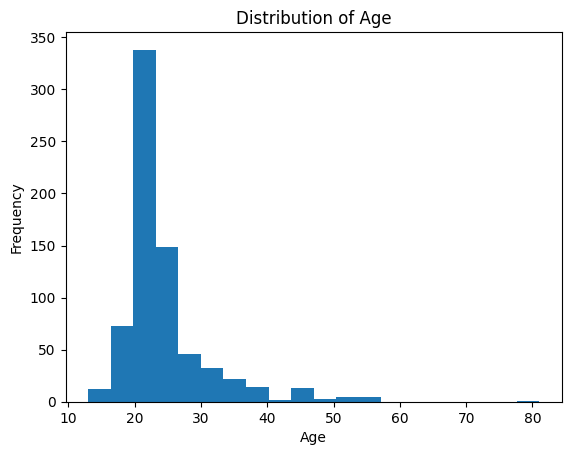

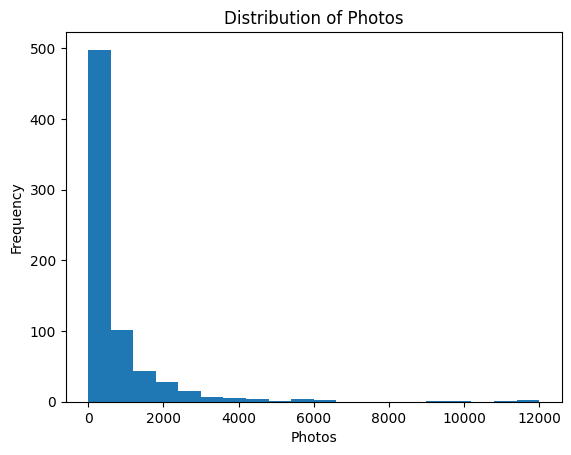

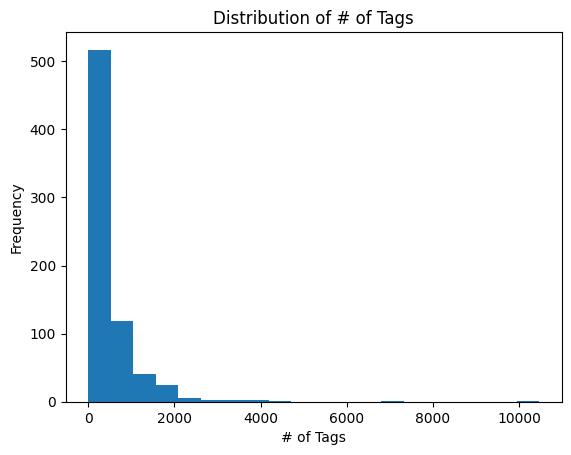

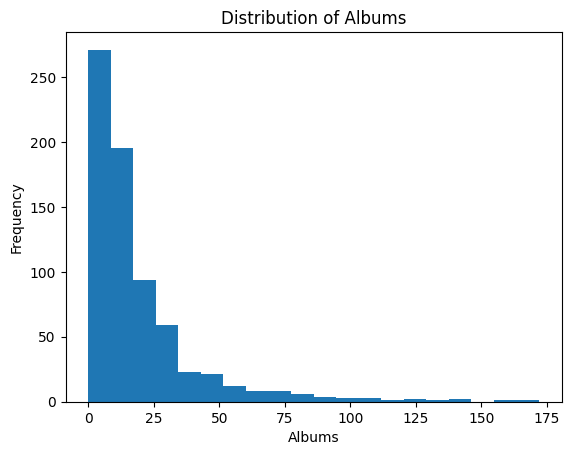

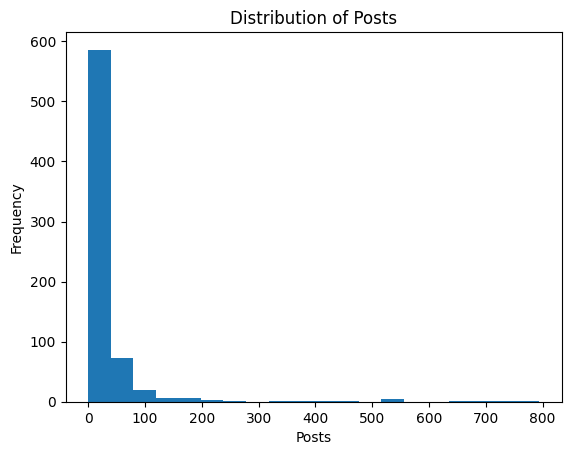

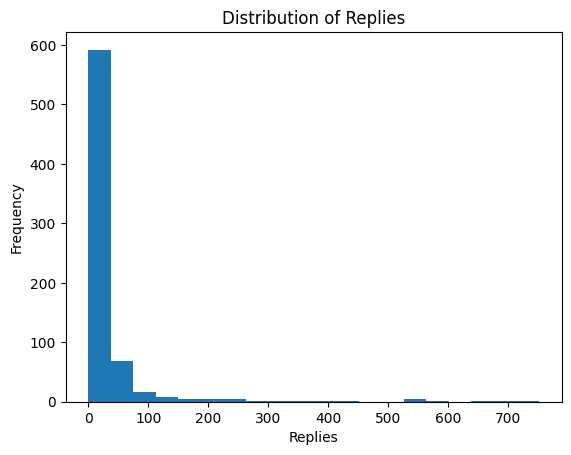

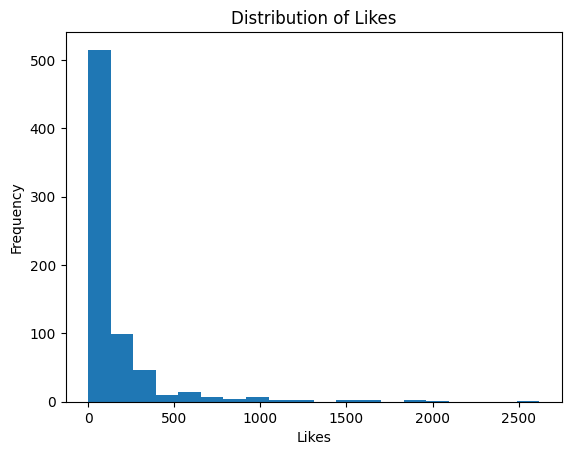

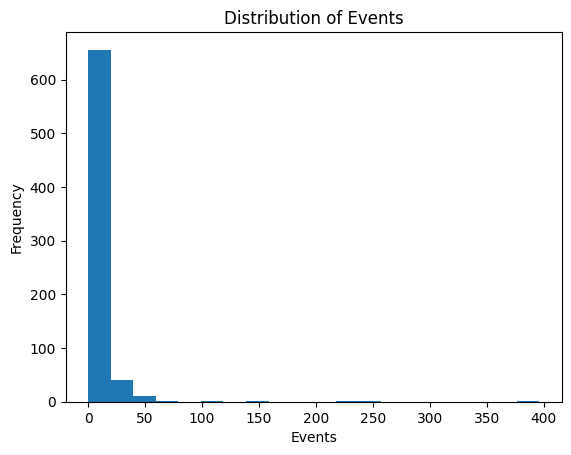

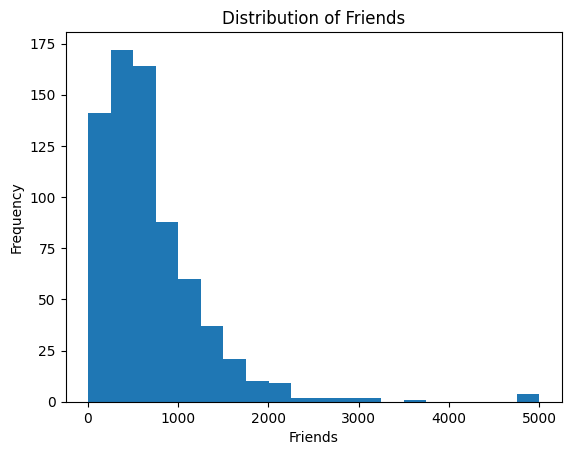

In [ ]:
continuous_cols = [
    "Age",
    "Photos",
    "# of Tags",
    "Albums",
    "Posts",
    "Replies",
    "Likes",
    "Events",
    "Friends"
]
# Plot histograms to see distribution patterns
for column in continuous_cols:
    plt.figure()
    plt.hist(df[column], bins=20)
    plt.title("Distribution of " + column)
    plt.xlabel(column)
    plt.ylabel("Frequency")
    plt.show()



---


**Data Visualization Interpretation:**


The histograms show that most users are between 18 and 25 years old.

The Friends, Photos, and Tags variables are clearly right-skewed. Most users have moderate activity, but a few users have extremely high values, creating outliers.

Posts and Replies show a similar pattern — most users are moderately active, while a small number are very active.


---



In [ ]:
import numpy as np

numeric_cols = df.select_dtypes(include=np.number).columns

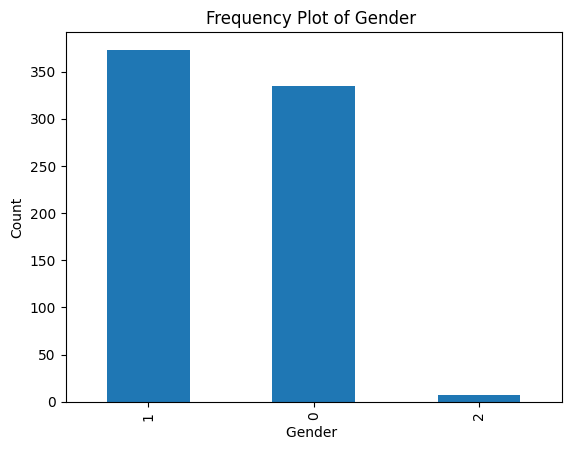

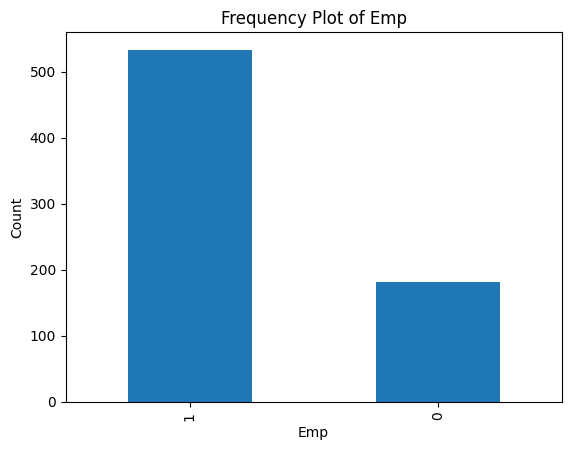

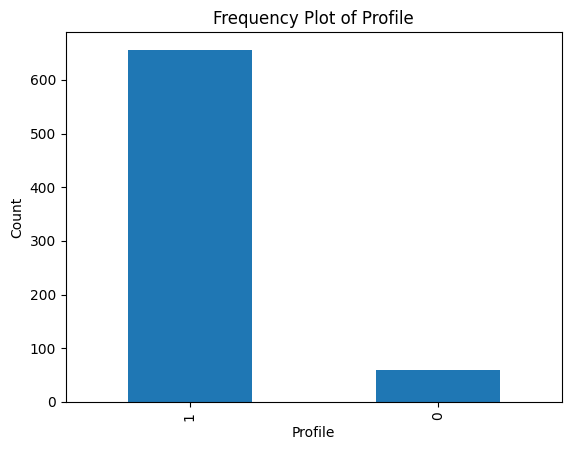

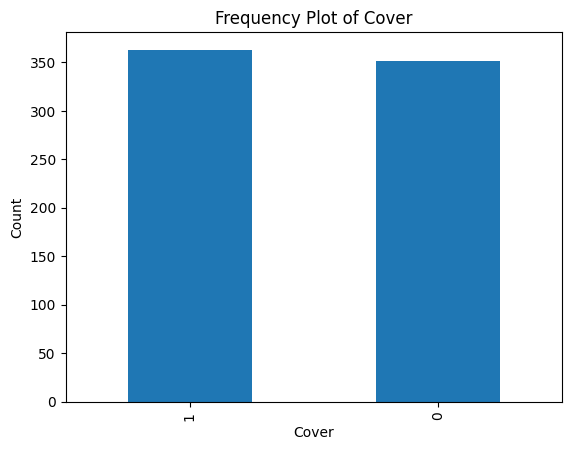

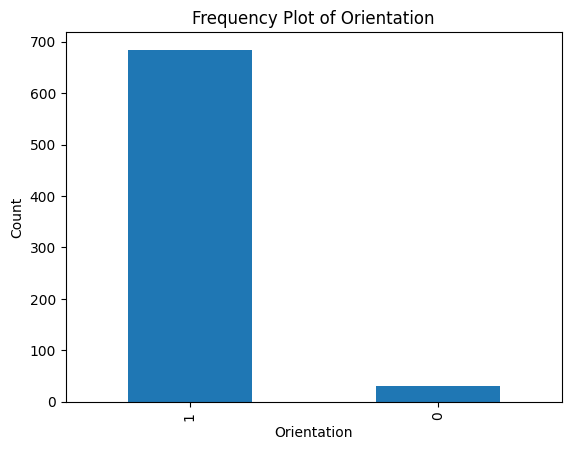

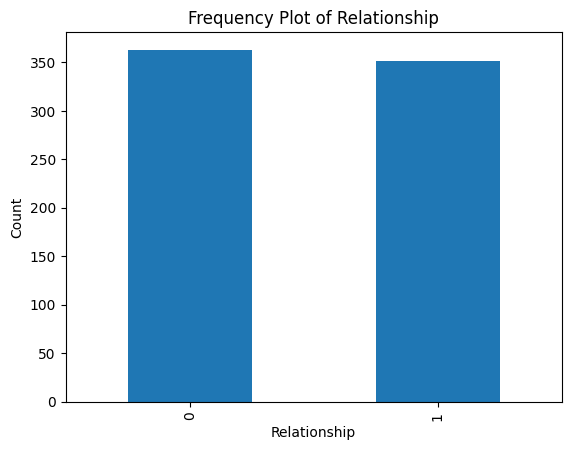

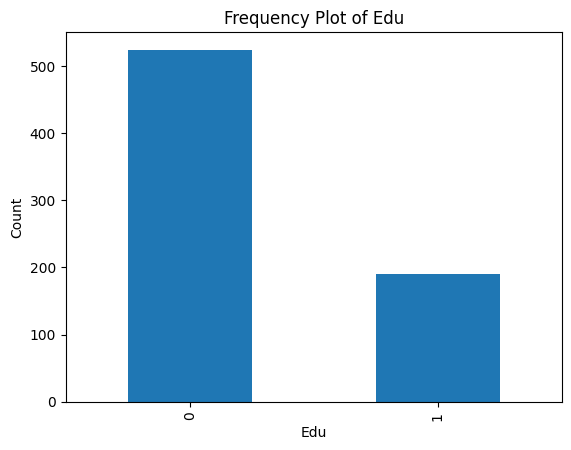

In [ ]:
for col in numeric_cols:
    if df[col].nunique() <= 5:
        plt.figure()
        df[col].value_counts().plot(kind="bar")
        plt.xlabel(col)
        plt.ylabel("Count")
        plt.title(f"Frequency Plot of {col}")
        plt.show()



---


**Frequency Plot (Bar Graph) Interpretation:**

Bar graphs were created for binary variables like Gender, Relationship, Emp, Profile, and Cover.

These graphs show how many users fall into each category (0 or 1). They make it easy to compare proportions between groups.

Some categories are much more common than others, which helps us understand general user characteristics.


---





---


**How Data Visualization Helps**

Data visualization helps us see patterns more clearly than tables alone.

It makes it easier to spot skewness, outliers, and differences between categories. From the graphs, it’s clear that user activity is not evenly distributed and a small number of users are much more active than the rest.


---



